In [ ]:
import os

# jax device and parallelization flags on m4 mac.
# modify as needed.
os.environ["JAX_PLATFORM_NAME"] = "cpu"
os.environ["XLA_FLAGS"] = "--xla_force_host_platform_device_count=12"

import sys
sys.path.append('../../src/')

import numpy as onp
import jax
import jax.numpy as jnp

from myutils import Ntime, ACFs, set_detectors
from myutils import ln_likelihood_full_jit

from scipy.linalg import toeplitz
import scipy.signal as sig

import lal
from gwpy.timeseries import TimeSeries
from other_utils import bandpass_ds, analysis_data, interp1d_jax, load_tables

jax.config.update("jax_enable_x64", True) 

/Users/kallol/Work/Misc/ringdown__2/examples/fixed-sky/../../src/myutils.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from chainconsumer import Chain, ChainConsumer, Truth, ChainConfig, PlotConfig

import numpyro
from numpyro.contrib.nested_sampling import NestedSampler
import numpyro.distributions as dist
numpyro.enable_x64()

/Users/kallol/miniconda3/envs/skyloc_ringdown/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
plt.rcParams["axes.grid"] = False

# Data download parameters

In [4]:
tgps = 1420878141.235932
tM = 0.337e-3 
tgps = tgps + 6*tM

seglen = 8
fs = 16384
fmin = 30
fmax       = 1500
event_id = "GW250114"
plot_checks = 0
T = 0.2
srate = 4096

ra = 2.33
dec = 0.190
psi = 1.329

factor = 10
seed       = 31567
t0         = 0.0

qnm1_path  = "../../data/l2/n1l2m2.dat"
qnm2_path  = "../../data/l2/n2l2m2.dat"

In [ ]:
dH1 = TimeSeries.fetch_open_data('H1', tgps - seglen/2, tgps + seglen/2, sample_rate=fs)
dL1 = TimeSeries.fetch_open_data('L1', tgps - seglen/2, tgps + seglen/2, sample_rate=fs)


n_analyze = Ntime(srate, T)

delays = {}
tgps_ = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_)
dt_ifo = delays.get('H1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLHODIFF].location, ra, dec, tgps))
tH1 = tgps + dt_ifo

delays = {}
tgps_ = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps_)
dt_ifo = delays.get('L1',
                    lal.TimeDelayFromEarthCenter(lal.CachedDetectors[lal.LALDetectorIndexLLODIFF].location, ra, dec, tgps))
tL1 = tgps + dt_ifo


dH1_cond = bandpass_ds(dH1, t0=tH1, ds=int(fs/srate), trim=0.25, f_min=fmin)
dL1_cond = bandpass_ds(dL1, t0=tL1, ds=int(fs/srate), trim=0.25, f_min=fmin)

# data strain starting from the respective detector times as calculated from tgps and sky location
# for the Fixed-sky analysis
dH1_analysis_data = analysis_data(dH1_cond[1], dH1_cond[0], tH1, n_analyze)
dL1_analysis_data = analysis_data(dL1_cond[1], dL1_cond[0], tL1, n_analyze)

nperseg = int(seglen * (1/(dH1.times.value[1] - dH1.times.value[0])))
noverlap = nperseg // 2

psdH = sig.welch(
    dH1.value,
    fs=fs,
    window="hann",
    nperseg=4096*4,
    noverlap=4096*2,
    detrend=False,
    return_onesided=True,
    scaling="density",  
)

psdL = sig.welch(
    dL1.value,
    fs=fs,
    window="hann",
    nperseg=4096*4,
    noverlap=4096*2,
    detrend=False,
    return_onesided=True,
    scaling="density",    
)

In [ ]:

dt_np = 1.0 / srate
Nt     = Ntime(srate=srate, T=T)
freqs_np = onp.fft.rfftfreq(Nt, d=dt_np)

fmin_eff = freqs_np[0]  if (fmin is None) else float(fmin)
fmax_eff = freqs_np[-1] if (fmax is None) else float(fmax)

i0 = int(onp.searchsorted(freqs_np, fmin_eff, side="left"))
i1 = int(onp.searchsorted(freqs_np, fmax_eff, side="right"))

freqs = jnp.asarray(freqs_np, dtype=jnp.float64)

# Prior limits
limits = [
    [55.0, 95.0],
    [0., 0.99],
    [0., 4.0],
    [0., 6.283185307179586],
    [0., 4.0],
    [0., 6.283185307179586],
    [-1., 1.],
    [0., 3.141592653589793]]

low  = onp.asarray([pair[0] for pair in limits], dtype=onp.float64)
high = onp.asarray([pair[1] for pair in limits], dtype=onp.float64)

In [7]:
psdH = interp1d_jax(jnp.asarray(psdH[0],dtype=jnp.float64), jnp.asarray(psdH[1],dtype=jnp.float64))
psdL = interp1d_jax(jnp.asarray(psdL[0],dtype=jnp.float64), jnp.asarray(psdL[1],dtype=jnp.float64))

omega_r, omega_i, omega_OT_r, omega_OT_i = load_tables(qnm1_path, qnm2_path)
tgps = lal.LIGOTimeGPS(tgps)
gmst = lal.GreenwichMeanSiderealTime(tgps)

rhoH, rhoL = ACFs(srate=srate, T=T, psdH=psdH, psdL=psdL, factor=factor)
covH=toeplitz(rhoH)
covL=toeplitz(rhoL)
L_H=jnp.linalg.cholesky(covH)
L_L=jnp.linalg.cholesky(covL)

resp_H_py = lal.CachedDetectors[lal.LALDetectorIndexLHODIFF].response
resp_L_py = lal.CachedDetectors[lal.LALDetectorIndexLLODIFF].response
resp_H = jnp.asarray(resp_H_py, dtype=jnp.float64)
resp_L = jnp.asarray(resp_L_py, dtype=jnp.float64)

set_detectors(resp_H, resp_L)

In [8]:
h_H_t = dH1_analysis_data[1]
h_L_t = dL1_analysis_data[1]

# jax numpyro sampling model

In [10]:
low  = jnp.asarray(low,  dtype=jnp.float64)  
high = jnp.asarray(high, dtype=jnp.float64) 

theta_fixed_sky = jnp.array([ra, onp.sin(dec)]) 

def make_loglik_fn(dataH, dataL, gmst, L_H, L_L,
                   omega_r, omega_i, omega_OT_r, omega_OT_i,
                   T, srate, t0):
    def _loglik(theta):
        return ln_likelihood_full_jit(
            dataH=dataH, dataL=dataL, params=theta,
            gmst=gmst, L_H=L_H, L_L=L_L,
            omega_r=omega_r, omega_i=omega_i,
            omega_OT_r=omega_OT_r, omega_OT_i=omega_OT_i,
            T=T, srate=srate, t0=t0
        )
    return _loglik

loglik_fn = make_loglik_fn(
    dataH=h_H_t, dataL=h_L_t,
    gmst=gmst, L_H=L_H, L_L=L_L,
    omega_r=omega_r, omega_i=omega_i,
    omega_OT_r=omega_OT_r, omega_OT_i=omega_OT_i,
    T=T, srate=srate, t0=t0
)

def model_fixed_sky():
    theta_free = numpyro.sample("theta", dist.Uniform(low, high))
    theta = jnp.concatenate([theta_free[:-1], theta_fixed_sky, jnp.array([theta_free[-1]])], axis=0)
    numpyro.factor("loglike", loglik_fn(theta))

In [11]:
rng_key = jax.random.PRNGKey(int(seed) ^ 0xABCDEF)
rng_run, rng_post = jax.random.split(rng_key)
ns_fixed_sky = NestedSampler(
    model_fixed_sky,
    constructor_kwargs=dict(
        num_live_points=10000,   
        max_samples=500_000,   
        verbose=True,
    ),
    termination_kwargs=dict(
        dlogZ=0.01,             
    ),
)
ns_fixed_sky.run(rng_run)
ns_fixed_sky.print_summary()
posterior_fixed_sky = ns_fixed_sky.get_samples(rng_post, num_samples=100_000)

INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
Creating initial state with 10008 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationCondition(ess=None, evidence_uncert=None, live_evidence_frac=None, dlogZ=Array(0.01, dtype=float64, weak_type=True), max_samples=Array(500400, dtype=int64), max_num_likelihood_evaluations=None, log_L_contour=None, efficiency_threshold=None, rtol=None, atol=None, peak_XL_frac=None)
-------
Num samples: 5004
Num likelihood evals: 240712
Efficiency: 0.04072994839570887
log(L) contour: -4458.2732260641105
log(Z) est.: -777.0782889780168 +- 0.8275312623446024
log(Z | remaining) est.: 3691.1746327148658 +- 1.0812158113961035
ESS: 0.5084189489413514

-------
Num samples: 10008
Num likelihood evals: 516949
Efficiency: 0.025069637883008356
log(L) contour: -2002.8305812027602
log(Z) est.: -767.8828094563612 +- 0.8305987860121125
log(Z | remaining) est.: 1244.2070878306397 +- 0.9327314492266584
ESS: 0.5032687810560524

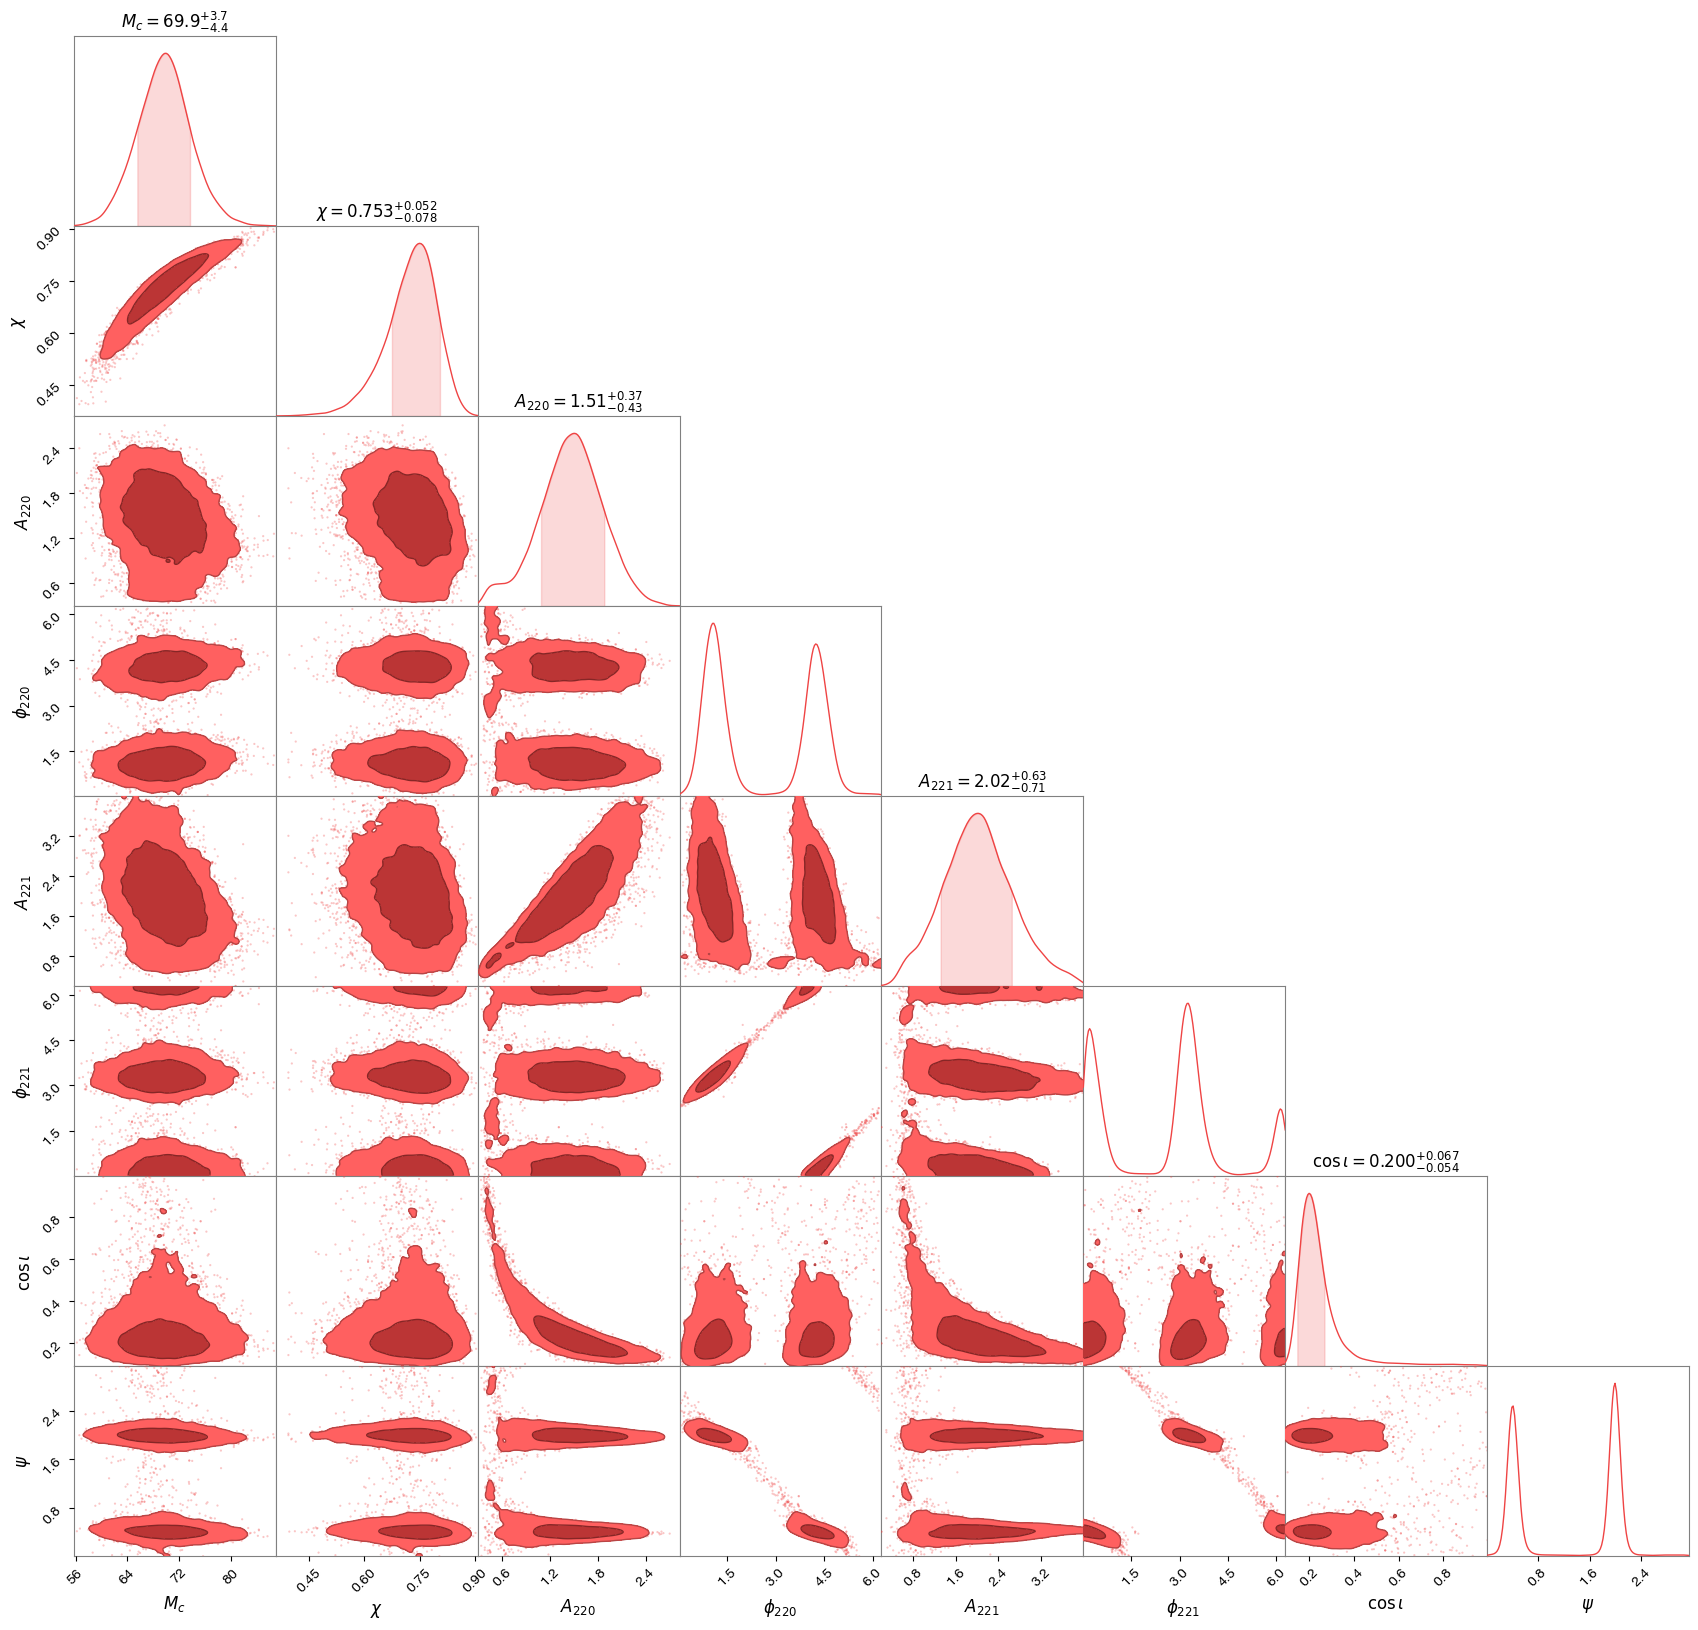

In [ ]:
ns_fixed_tail_parameters = [r'$M_c$', r'$\chi$', r'$A_{220}$', r'$\phi_{220}$', r'$A_{221}$', r'$\phi_{221}$', r'$\cos\iota$', r'$\psi$']


df_ns_fixed_ext = pd.DataFrame(posterior_fixed_sky['theta'], columns=ns_fixed_tail_parameters)
c = ChainConsumer()
c.add_chain(Chain(samples=df_ns_fixed_ext, color='r', name="Fixed sky"))
c.set_override(ChainConfig(sigmas=[0, 1, 2], plot_cloud=1))
c.set_plot_config(
    PlotConfig(
        contour_label_font_size=24,
        legend_kwargs={'fontsize': 30}
    )
)
fig = c.plotter.plot()
# plt.savefig(corner_path, dpi=300, bbox_inches='tight')
plt.show()

In [13]:
onp.save('posterior.' + event_id + '.fixed-sky.npy', onp.asarray(posterior_fixed_sky['theta']))

In [14]:
ns_fixed_sky._results.log_Z_mean

Array(-739.49449767, dtype=float64)

In [15]:
limits = [
    [55.0, 95.0],
    [0., 0.99],
    [0., 4.0],
    [0., 6.283185307179586],
    [-1., 1.],
    [0., 3.141592653589793]]

low  = onp.asarray([pair[0] for pair in limits], dtype=onp.float64)
high = onp.asarray([pair[1] for pair in limits], dtype=onp.float64)

In [16]:
low  = jnp.asarray(low,  dtype=jnp.float64)  
high = jnp.asarray(high, dtype=jnp.float64) 

theta_fixed_sky = jnp.array([ra, dec]) 

def make_loglik_fn(dataH, dataL, gmst, L_H, L_L,
                   omega_r, omega_i, omega_OT_r, omega_OT_i,
                   T, srate, t0):
    def _loglik(theta):
        return ln_likelihood_full_jit(
            dataH=dataH, dataL=dataL, params=theta,
            gmst=gmst, L_H=L_H, L_L=L_L,
            omega_r=omega_r, omega_i=omega_i,
            omega_OT_r=omega_OT_r, omega_OT_i=omega_OT_i,
            T=T, srate=srate, t0=t0
        )
    return _loglik

loglik_fn = make_loglik_fn(
    dataH=h_H_t, dataL=h_L_t,
    gmst=gmst, L_H=L_H, L_L=L_L,
    omega_r=omega_r, omega_i=omega_i,
    omega_OT_r=omega_OT_r, omega_OT_i=omega_OT_i,
    T=T, srate=srate, t0=t0
)

def model_fixed_sky_220():
    theta_free = numpyro.sample("theta", dist.Uniform(low, high))
    amp_phase_221 = jnp.array([0., 0.])
    theta = jnp.concatenate([theta_free[:4], amp_phase_221, theta_free[4:5], theta_fixed_sky, jnp.array([theta_free[-1]])], axis=0)
    numpyro.factor("loglike", loglik_fn(theta))

In [17]:
rng_key = jax.random.PRNGKey(int(seed) ^ 0xABCDEF)
rng_run, rng_post = jax.random.split(rng_key)
ns_fixed_sky_220 = NestedSampler(
    model_fixed_sky_220,
    constructor_kwargs=dict(
        num_live_points=10000,   
        max_samples=500_000,   
        verbose=True,
    ),
    termination_kwargs=dict(
        dlogZ=0.01,             
    ),
)
ns_fixed_sky_220.run(rng_run)
ns_fixed_sky_220.print_summary()
posterior_fixed_sky_220 = ns_fixed_sky_220.get_samples(rng_post, num_samples=100_000)

INFO:jaxns:Number of Markov-chains set to: 10000


Running over 12 devices.
Creating initial state with 10008 live points.
Running uniform sampling down to efficiency threshold of 0.1.
Running until termination condition: TerminationCondition(ess=None, evidence_uncert=None, live_evidence_frac=None, dlogZ=Array(0.01, dtype=float64, weak_type=True), max_samples=Array(500400, dtype=int64), max_num_likelihood_evaluations=None, log_L_contour=None, efficiency_threshold=None, rtol=None, atol=None, peak_XL_frac=None)
-------
Num samples: 5004
Num likelihood evals: 181477
Efficiency: 0.05366766587480762
log(L) contour: -3676.5042762747357
log(Z) est.: -750.4582684009258 +- 0.8323869828338734
log(Z | remaining) est.: 2936.0849695418256 +- 1.0844467909871467
ESS: 0.500254204704387

-------
Num samples: 10008
Num likelihood evals: 392208
Efficiency: 0.03313720750818663
log(L) contour: -1495.4306566777223
log(Z) est.: -750.9544286359109 +- 0.831436537828916
log(Z | remaining) est.: 752.8130464040477 +- 0.8793224910216545
ESS: 0.5018656675892729

--

In [18]:
ns_fixed_sky_220._results.log_Z_mean

Array(-746.22803126, dtype=float64)

In [18]:
ns_fixed_sky_220._results.log_Z_mean

Array(-746.04421353, dtype=float64)

In [19]:
ns_fixed_sky._results.log_Z_mean - ns_fixed_sky_220._results.log_Z_mean

Array(6.73353359, dtype=float64)

In [19]:
ns_fixed_sky._results.log_Z_mean - ns_fixed_sky_220._results.log_Z_mean

Array(6.54971586, dtype=float64)